## Cheap or Skilled? what purpose does H-1B really serve?
By: Summer Negahdar

**Revelio Lab's weekly newletter**


In [2]:
## first, importing the basic libraries!
from pytrends.request import TrendReq
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from glob import glob
from pathlib import Path


Talk about president trump constantly talking about immigrants, visa 

In [ ]:

plt.style.use('seaborn-v0_8')

pytrends = TrendReq(hl='en-US', tz=360, timeout=(10,25))
## ================== Reduced Keyword List (max 5) ==================
keywords = ["H1B", "H-1B", "H1B visa", "OPT", "visa"]

print("Fetching data... (this may take a few seconds)")

pytrends.build_payload(keywords, 
                       timeframe='2022-11-01 2026-04-25', 
                       geo='US')

df = pytrends.interest_over_time()

# ================== Clustering ==================
df['H1B_Cluster'] = df[["H1B", "H-1B", "H1B visa"]].mean(axis=1)
df['OPT_Cluster']  = df[["OPT"]].mean(axis=1)

Fetching data... (this may take a few seconds)


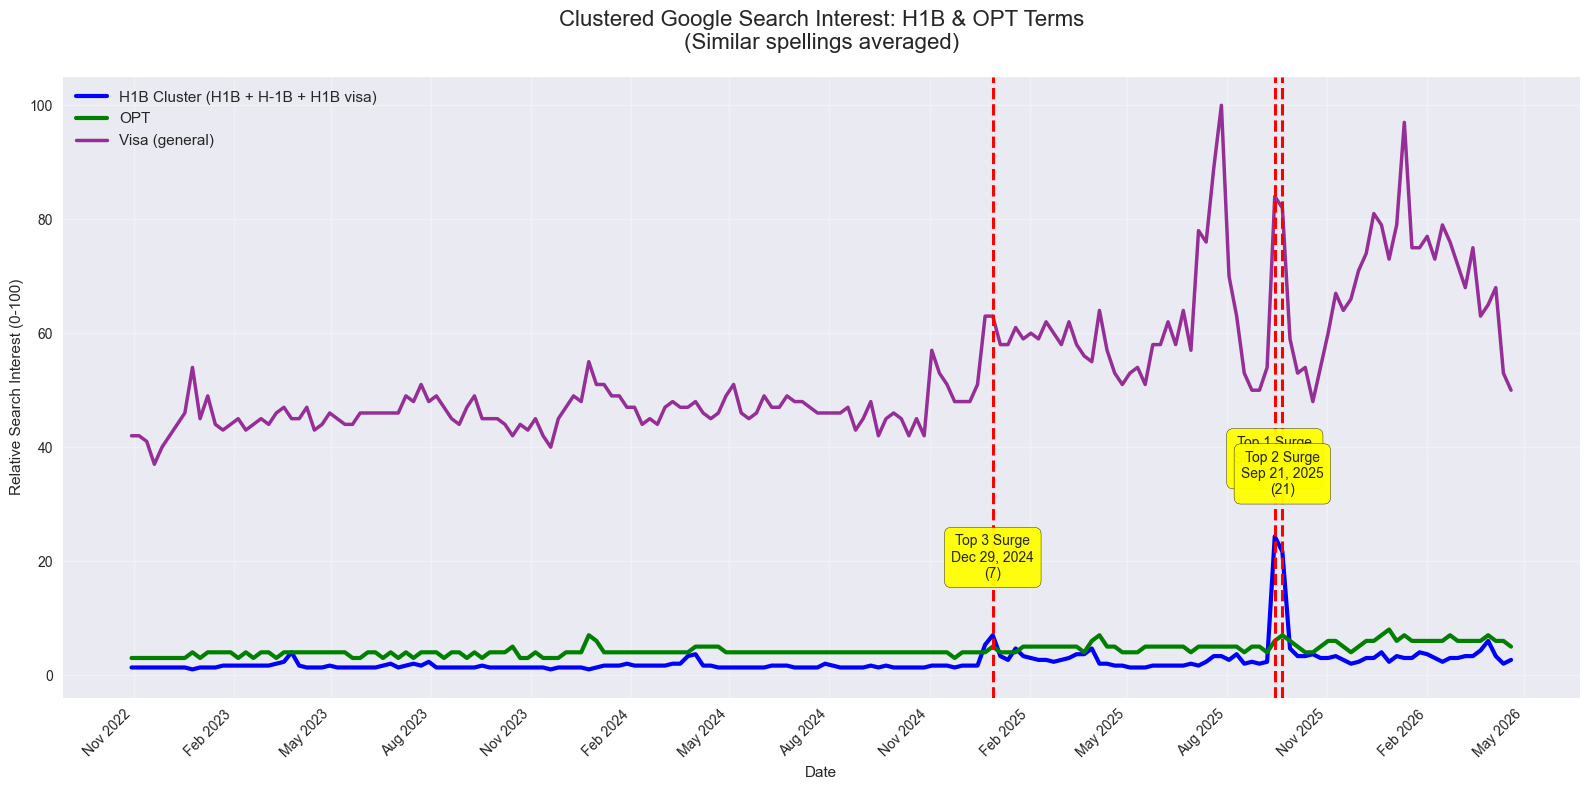

In [15]:
# ================== Plot ==================
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(df.index, df['H1B_Cluster'], label='H1B Cluster (H1B + H-1B + H1B visa)', linewidth=3, color='blue')
ax.plot(df.index, df['OPT_Cluster'],  label='OPT', linewidth=3, color='green')
ax.plot(df.index, df['visa'], label='Visa (general)', linewidth=2.5, color='purple', alpha=0.8)

# Auto Top 3 Surges
top3 = df['H1B_Cluster'].nlargest(3)
for i, (date, value) in enumerate(top3.items(), 1):
    ax.axvline(x=date, color='red', linestyle='--', linewidth=2.2)
    ax.annotate(f'Top {i} Surge\n{date.strftime("%b %d, %Y")}\n({int(value)})',
                xy=(date, value + 4),
                xytext=(0, 25), textcoords='offset points',
                ha='center', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.5", facecolor="yellow", alpha=0.95))

# Formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))

plt.title("Clustered Google Search Interest: H1B & OPT Terms\n(Similar spellings averaged)", 
          fontsize=16, pad=20)
plt.xlabel("Date")
plt.ylabel("Relative Search Interest (0-100)")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
# Show top surges
print("\n=== Top 3 Surges (H1B Cluster) ===")
print(top3)


=== Top 3 Surges (H1B Cluster) ===
date
2025-09-14    24.333333
2025-09-21    21.666667
2024-12-29     7.000000
Name: H1B_Cluster, dtype: float64


December 29, 2024 was the day a new "weighted policy" for H1B applications was announced, which likely caused a surge in interest. 
The other two surges both happened after Trump administration announced a new 100k fee imposed onto new H1-B applicants applying from utside USA. (September 21st was the day effective and 14th was initial date.)

In [ ]:
## now loading our company mapping dataset( for later)
CompMap_df = pd.read_csv("H1B_Newsletter/company_mapping.csv")
print(CompMap_df.head())


       rcid                                       company  \
0    350953                               Microsoft Corp.   
1   1292281                  Advanced Micro Devices, Inc.   
2    766823                                Alphabet, Inc.   
3  22144072  Taiwan Semiconductor Manufacturing Co., Ltd.   
4   1311350                                   Intel Corp.   

                                   primary_name factset_entity_id  \
0                               Microsoft Corp.          000Q07-E   
1                  Advanced Micro Devices, Inc.          000BK7-E   
2                                Alphabet, Inc.          0FPWZZ-E   
3  Taiwan Semiconductor Manufacturing Co., Ltd.          001Y70-E   
4                                   Intel Corp.          000N01-E   

   year_founded ticker          exchange_name   sedol          isin  \
0          1975   MSFT                 NASDAQ  258817  US5949181045   
1          1969    AMD                 NASDAQ  200784  US0079031078   
2    

In [4]:
## combining the postings individual linkedin datasets into one
folder_path = "H1B_Newsletter/postings_linkedin_individual" 


# Find all CSV files (including subfolders if any)
csv_files = glob(f"{folder_path}/**/*.csv", recursive=True)

print(f"Found {len(csv_files)} CSV files")

# Load and combine them all
postings = pd.concat(
    (pd.read_csv(f) for f in csv_files),
    ignore_index=True
)

print("Combined shape:", postings.shape)
print("Columns:", postings.columns.tolist())

Found 32 CSV files
Combined shape: (4308312, 21)
Columns: ['job_id', 'rcid', 'company', 'rics_k50', 'rics_k200', 'rics_k400', 'title_raw', 'title_translated', 'role_k10', 'role_k50', 'role_k150', 'role_k1500', 'mapped_role', 'country', 'state', 'salary', 'post_date', 'remove_date', 'ultimate_parent_rcid', 'ultimate_parent_company_name', 'remote_type']


In [9]:
# ================== Save as one CSV ==================
output_filename_p = "postings_combined.csv"

postings.to_csv(output_filename_p, index=False)

print(f" Successfully saved as '{output_filename_p}'")
print(f"File size: {postings.shape[0]:,} rows × {postings.shape[1]} columns")

 Successfully saved as 'postings_combined.csv'
File size: 1,103,593 rows × 21 columns


In [8]:
print(postings.head(10))

                   job_id     rcid                       company  \
1              4029671745   350953               Microsoft Corp.   
4              3442789037   341560              Activision, Inc.   
13             3974963511   350953               Microsoft Corp.   
19             4052300060   350953               Microsoft Corp.   
21             3720377867   350953               Microsoft Corp.   
23  353285934800000000002  1292281  Advanced Micro Devices, Inc.   
25             4033583916   350953               Microsoft Corp.   
37             3887167198   350953               Microsoft Corp.   
42  391066627200000000002   350953               Microsoft Corp.   
48             4029676065   350953               Microsoft Corp.   

                           rics_k50                                 rics_k200  \
1   Information Technology Services       Enterprise Software and IT Services   
4           Media and Entertainment     Video Game Development and Publishing   
13  Info

In [5]:
# Convert posting date to proper datetime
postings['post_date'] = pd.to_datetime(postings['post_date'], errors='coerce')
# Original full range
print("=== ORIGINAL FULL DATE RANGE ===")
print("Earliest posting:", postings['post_date'].min())
print("Latest posting:  ", postings['post_date'].max())
print("Total postings:  ", len(postings))

# Quick breakdown by year (very useful)
print("\n=== Postings by Year ===")
print(postings['post_date'].dt.year.value_counts().sort_index())



=== ORIGINAL FULL DATE RANGE ===
Earliest posting: 2020-05-10 00:00:00
Latest posting:   2025-09-07 00:00:00
Total postings:   4308312

=== Postings by Year ===
post_date
2020      61263
2021    1671690
2022    1583011
2023     292533
2024     491105
2025     208710
Name: count, dtype: int64


In [7]:
# Filter to the period starting before Trump's announcement
postings = postings[postings['post_date'] >= '2022-11-01'].copy()

print("Final shape after date filter:", postings.shape)
print("Date range:", postings['post_date'].min(), "→", postings['post_date'].max())

Final shape after date filter: (1103593, 21)
Date range: 2022-11-01 00:00:00 → 2025-09-07 00:00:00


This would not work as the cutoff is before September 14th. but I really liked the topic!
This would have been the next steps: 
1. find companies with offices inside and outside USA (Europe, Asia, India, ME)>> (to show there is a 'choice')

2. find the ratio of hires inside Vs. ourside USA for all these companies (just cluster USA/ Non-USA)

3. filter top 5-10 companies (mostly probably in tech, semiconductor, finance)

4. draw an RDD plot aorund september 14-21

**Hypothesis Testing:**

    a. if they suddenly increase their outbound hires, maybe it is a sign that the jobs could have been done by americans and it was just a matter of "cost"
    
    b. if they still hire non-american/ non-citizens for USA office> then maybe it is a signal that H-1B was never a way to hire cheap labor, rather skilled labor